Practica 3 - parte 2
- Juan Basante
- Michael Salazar

In [2]:
import mne
# Import other libraries
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 
from scipy import stats # Nos permite realizar análisis estadísticos
from scipy import signal # Nos permite realizar preprocesmaiento de la señal
import numpy as np
import warnings
warnings.filterwarnings("ignore") # Ignorar advertencias 
mne.set_log_level("WARNING") # Configurar el nivel de registro de MNE a "WARNING" para reducir la cantidad de mensajes de registro

In [3]:
RUTA_DATOS = r"C:\Users\basan\Desktop\LaboratorioBiosenales\Lab_Bios\datos\files"

In [6]:
print(os.path.exists(RUTA_DATOS))

True


In [13]:
#parametros
SUJETOS     = list(range(1, 11))
RUNS        = [4, 8, 12] # Tarea 2 imaginar mano izq/der
#3 canales ubicados sobre la corteza motora 
CANALES_ROI = ['C3', 'Cz', 'C4'] #region of interest
TMIN, TMAX  = 0.5, 3.5  #tiempo de interés para el análisis
BANDA_FREC  = (8, 30) 

# T1 = mano izquierda  código 2
# T2 = mano derecha    código 3
ID_T1 = 2
ID_T2 = 3

In [15]:
def ruta_edf(sujeto, run):
    carpeta = f"S{sujeto:03d}" #3 dijitos  
    archivo = f"S{sujeto:03d}R{run:02d}.edf" #3 dijistos y 2 dijitos
    return os.path.join(RUTA_DATOS, carpeta, archivo)

In [25]:
print(raw.ch_names)

['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


1. Cálcular la amplitud efectiva RMS 

In [ ]:
def calcular_rms_promedio(epochs):
    """  
        epochs : mne.Epochs
        Señal segmentada, shape (n_épocas, n_canales, n_tiempos)

    Retorna
    dict : {nombre_canal: rms_promedio}
    """

    # Extraer datos numéricos
    # shape: (n_épocas, n_canales, n_tiempos)
    data = epochs.get_data()

    # RMS por época y canal sobre el eje del tiempo
    rms_por_epoca = np.sqrt(np.mean(data**2, axis=2))

    # Promedio sobre todas las epocas
    # shape resultante: (n_canales,)
    rms_promedio = np.mean(rms_por_epoca, axis=0)

    #guardar resultafo en un diccionario 
    return dict(zip(epochs.ch_names, rms_promedio))

2. Construcción de la Base de datos poblacional

In [39]:
#guardar resultados
resultados_T1 = []
resultados_T2 = []

for sujeto in SUJETOS:
    
    print(f"Procesando sujeto S{sujeto:03d}")
    
    raws = []
    
    #cargar runs
    for run in RUNS:
        ruta = ruta_edf(sujeto, run)
        
        if not os.path.exists(ruta):
            continue
        
        raw = mne.io.read_raw_edf(ruta, preload=True, verbose=False)
        raws.append(raw)
    
    if len(raws) == 0:
        continue
    
    #concatenar
    raw = mne.concatenate_raws(raws)
    
    #limpiar nombres
    raw.rename_channels(lambda x: x.replace('.', '').strip().upper())
    
    # canales
    raw.pick_channels(['C3', 'CZ', 'C4'])
    
    #filtrar
    raw.filter(BANDA_FREC[0], BANDA_FREC[1], verbose=False)
    
    #eventos
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    epochs = mne.Epochs(
        raw,
        events,
        event_id={'T1': ID_T1, 'T2': ID_T2},
        tmin=TMIN,
        tmax=TMAX,
        baseline=None,
        preload=True,
        verbose=False
    )
    
    #separar clases
    epochs_T1 = epochs['T1']
    epochs_T2 = epochs['T2']
    
    # RMS promedio por canal
    rms_T1 = calcular_rms_promedio(epochs_T1)
    rms_T2 = calcular_rms_promedio(epochs_T2)
    
    # guardar resultados
    resultados_T1.append(rms_T1)
    resultados_T2.append(rms_T2)

#CREAR DATAFRAMES
df_izquierda = pd.DataFrame(resultados_T1, index=[f"S{i:03d}" for i in SUJETOS])
df_derecha   = pd.DataFrame(resultados_T2, index=[f"S{i:03d}" for i in SUJETOS])

print("\nDataFrame Mano Izquierda (T1)")
print(df_izquierda)

print("\nDataFrame Mano Derecha (T2) ")
print(df_derecha)

Procesando sujeto S001
Procesando sujeto S002
Procesando sujeto S003
Procesando sujeto S004
Procesando sujeto S005
Procesando sujeto S006
Procesando sujeto S007
Procesando sujeto S008
Procesando sujeto S009
Procesando sujeto S010

DataFrame Mano Izquierda (T1)
            C3        CZ        C4
S001  0.000019  0.000019  0.000016
S002  0.000012  0.000014  0.000010
S003  0.000022  0.000021  0.000020
S004  0.000008  0.000008  0.000008
S005  0.000009  0.000009  0.000008
S006  0.000010  0.000009  0.000009
S007  0.000017  0.000016  0.000014
S008  0.000010  0.000011  0.000010
S009  0.000022  0.000021  0.000023
S010  0.000020  0.000020  0.000017

DataFrame Mano Derecha (T2) 
            C3        CZ        C4
S001  0.000019  0.000019  0.000017
S002  0.000011  0.000014  0.000010
S003  0.000022  0.000021  0.000020
S004  0.000008  0.000009  0.000008
S005  0.000009  0.000009  0.000008
S006  0.000010  0.000009  0.000009
S007  0.000017  0.000018  0.000017
S008  0.000010  0.000011  0.000010
S009  0.0

3. Identificación de canales diferenciales mediante Análisis estadístico

- Prueba de normalidad: Shapiro-Wilk

p > 0.05 distribucio normal

p <= 0.05 No normal 

In [42]:
from scipy.stats import shapiro

print("\nPRUEBA DE NORMALIDAD (Shapiro-Wilk) ")

for canal in ['C3', 'CZ', 'C4']:
    
    datos_T1 = df_izquierda[canal].astype(float)
    datos_T2 = df_derecha[canal].astype(float)
    
    # Shapiro
    stat_T1, p_T1 = shapiro(datos_T1)
    stat_T2, p_T2 = shapiro(datos_T2)
    
    print(f"\nCanal: {canal}")
    print(f"T1 -> p = {p_T1:.5f}")
    print(f"T2 -> p = {p_T2:.5f}")
    
    # comparar
    if p_T1 > 0.05:
        print("T1: Distribución normal")
    else:
        print("T1: NO normal")
    
    if p_T2 > 0.05:
        print("T2: Distribución normal")
    else:
        print("T2: NO normal")


PRUEBA DE NORMALIDAD (Shapiro-Wilk) 

Canal: C3
T1 -> p = 0.07077
T2 -> p = 0.14730
T1: Distribución normal
T2: Distribución normal

Canal: CZ
T1 -> p = 0.09001
T2 -> p = 0.07800
T1: Distribución normal
T2: Distribución normal

Canal: C4
T1 -> p = 0.22098
T2 -> p = 0.15390
T1: Distribución normal
T2: Distribución normal


- Prueba de Homocedasticidad: Levene 

In [43]:
from scipy.stats import levene

print("\nPRUEBA DE HOMOCEDASTICIDAD (Levene)")

for canal in ['C3', 'CZ', 'C4']:
    
    datos_T1 = df_izquierda[canal].astype(float)
    datos_T2 = df_derecha[canal].astype(float)
    
    stat, p = levene(datos_T1, datos_T2)
    
    print(f"\nCanal: {canal}")
    print(f"p = {p:.5f}")
    
    if p > 0.05:
        print("Varianzas iguales (homocedasticidad)")
    else:
        print("Varianzas diferentes (heterocedasticidad)")


PRUEBA DE HOMOCEDASTICIDAD (Levene)

Canal: C3
p = 0.92727
Varianzas iguales (homocedasticidad)

Canal: CZ
p = 0.85396
Varianzas iguales (homocedasticidad)

Canal: C4
p = 0.78618
Varianzas iguales (homocedasticidad)


Se realizó una prueba t de Student para muestras independientes con el fin de determinar si existían diferencias estadísticamente significativas en la energía (RMS) de los canales de EEG entre las tareas de imaginería motora de mano izquierda (T1) y mano derecha (T2). La elección de esta prueba se fundamentó en la verificación previa de los supuestos estadísticos requeridos. En primer lugar, se aplicó la prueba de normalidad de Shapiro-Wilk, obteniéndose valores de p mayores a 0.05 para todos los canales en ambos grupos, lo que indica que los datos siguen una distribución aproximadamente normal. Posteriormente, se realizó la prueba de homocedasticidad de Levene, la cual evidenció valores de p superiores a 0.05, indicando igualdad de varianzas entre los grupos.

- t- Student

In [47]:
from scipy.stats import ttest_ind

print("\nPRUEBA t - Student ")

for canal in ['C3', 'CZ', 'C4']:
    
    datos_T1 = df_izquierda[canal].astype(float)
    datos_T2 = df_derecha[canal].astype(float)
    
    stat, p = ttest_ind(datos_T1, datos_T2)
    
    print(f"\nCanal: {canal}")
    print(f"p-valor = {p:.5f}")
    
    if p < 0.05:
        print(" Diferencia significativa")
    else:
        print("X -> NO hay diferencia significativa")


PRUEBA t - Student 

Canal: C3
p-valor = 0.95749
X -> NO hay diferencia significativa

Canal: CZ
p-valor = 0.96190
X -> NO hay diferencia significativa

Canal: C4
p-valor = 0.81936
X -> NO hay diferencia significativa


Aunque se observaron diferencias en los valores de RMS entre las condiciones, estas no resultaron estadísticamente significativas (p > 0.05). Esto puede deberse a la baja magnitud de las diferencias y la alta variabilidad intersujeto, características típicas de señales EEG

Se aplicó la prueba t de Student para muestras independientes con el objetivo de evaluar la existencia de diferencias estadísticamente significativas en la energía (RMS) de los canales C3, Cz y C4 entre las tareas de imaginación motora de mano izquierda (T1) y mano derecha (T2).

Los resultados obtenidos evidencian que los valores de p para todos los canales analizados fueron superiores a 0.05 (C3: p = 0.95749, Cz: p = 0.96190, C4: p = 0.81936). En consecuencia, no se rechaza la hipótesis nula, lo que indica que **no existen diferencias estadísticamente significativas entre las dos condiciones experimentales en ninguno de los canales evaluados.**

Por lo tanto, con base en este análisis, ninguno de los canales estudiados puede ser considerado como un canal diferencial clave para la discriminación entre tareas de imaginería motora en este conjunto de datos.

- Visualización 

Usamos C4 (aunque no sea significativo)

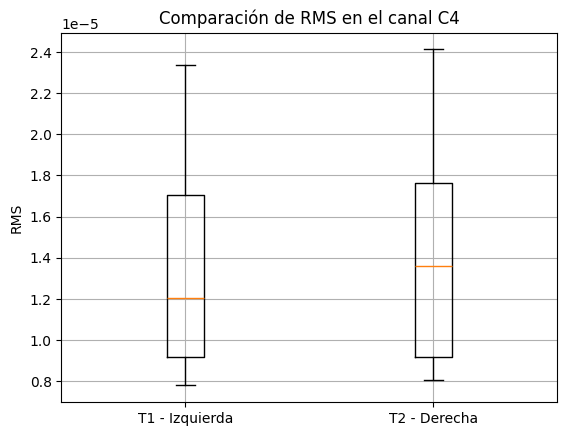

In [48]:
canal = 'C4'

datos_T1 = df_izquierda[canal].astype(float)
datos_T2 = df_derecha[canal].astype(float)

plt.figure()

plt.boxplot([datos_T1, datos_T2], labels=['T1 - Izquierda', 'T2 - Derecha'])

plt.title(f'Comparación de RMS en el canal {canal}')
plt.ylabel('RMS')
plt.grid()

plt.show()

Se construyó un diagrama de caja (boxplot) para el canal C4, el cual presentó el menor valor de p en el análisis estadístico. En la figura se comparó la distribución de los valores de RMS entre las condiciones de imaginería motora de mano izquierda (T1) y mano derecha (T2).

Se observa un alto grado de solapamiento entre las distribuciones, lo que indica que los valores de ambos grupos comparten rangos similares y no presentan una separación clara.

Estos resultados visuales son consistentes con el análisis estadístico previamente realizado mediante la prueba t de Student, donde no se encontraron diferencias significativas entre los grupos (p > 0.05). En consecuencia, el canal C4 no presenta un comportamiento diferencial suficiente para discriminar entre las tareas de imaginería motora evaluadas.